# Experiment 1.3.1 — Direct 30-channel event temporal-representation probe

This notebook extends Experiment 1.3 from **relative-progress temporal binning** to a broader direct-event representation study using the current **30 unsigned polarity-split weighted event channels** at the dataset-declared sampling rate (expected: 64 Hz).

The experiment asks four linked questions:

1. **Whole-count / relative-phase baseline:** how much class information is available when the valid gesture is summarized into 1, 2, 4, 10, or 20 relative-progress bins?
2. **Raw timestep flatten:** how linearly separable / locally clustered are the complete zero-padded event trains without temporal aggregation?
3. **Fixed-duration sweep:** how much class information remains when events are summed inside fixed physical windows from 50 ms to 1000 ms?
4. **Magnitude control:** for each fixed duration, does per-bin total-intensity normalization preserve accuracy, indicating that within-bin channel composition matters more than absolute event magnitude?

For every deterministic representation, the notebook evaluates both:

- multinomial **Logistic Regression** (Balanced Accuracy, Accuracy, Macro-F1), and
- **5-NN** (same metrics; Balanced Accuracy is the primary local-neighborhood / cluster proxy).

All conditions reuse one deterministic **user-disjoint train/validation/test split**. Validation metrics are included so a preferred fixed duration can be selected without choosing it directly on the test set.


In [1]:

from pathlib import Path
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root from current working directory")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/zhaolongwei_umass_edu/projects/writingRing
PyTorch: 2.11.0+cu128
CUDA available: False


## 1. Configuration

The representation contract is the current 30-channel unsigned polarity-split event schema. The fixed-duration sweep converts requested milliseconds to samples using `round(duration_ms * sampling_rate_hz / 1000)` and records the actual implemented duration. Each of `SPLIT_SEEDS = (11, 23, 37, 53, 71)` creates one shared user split for every representation.


In [2]:

# -----------------------------------------------------------------------------
# USER CONFIGURATION
# -----------------------------------------------------------------------------
ACTION0_COMBINATION_DIR = REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64"
ACTION1_COMBINATION_DIR = REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64"
DATASET_ROOTS = [
    ACTION0_COMBINATION_DIR / "low-pass/aligned-board-events/segmentation_padded",
    ACTION1_COMBINATION_DIR / "low-pass/aligned-board-events/segmentation_padded",
]

EXPECTED_EVENT_REPRESENTATION = "unsigned"
EXPECTED_EVENT_FEATURE_SCHEMA = "custom_wavelet_polarity_split_abs_events_v1"
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = EVENT_CHANNEL_COUNT + 6
EXPECTED_SAMPLING_RATE_HZ = 64.0

# Each seed creates one user-disjoint split shared by every representation.
SPLIT_SEEDS: tuple[int, ...] = (11, 23, 37, 53, 71)
TRAIN_FRACTION = 0.6
VAL_FRACTION = 0.2

# Ordered labels to retain; None keeps every label.
INCLUDED_LABELS: tuple[str, ...] | None = (
    "A", "B", "C", "D", "E", "X", "G", "H", "I", "J", "K", "L"
)

# Relative-progress baseline from Experiment 1.3.
RELATIVE_N_BINS = (1, 4, 10, 20)
RELATIVE_REFERENCE_N_BINS = 10

# Fixed physical-duration sweep.
FIXED_DURATIONS_MS = tuple(range(50, 1001, 100))
PER_BIN_NORMALIZATION_MODES = ("raw", "unit_total_intensity")

# Classifier / local-neighborhood probe settings.
KNN_K = 5
LOGREG_MAX_ITER = 5000

# These seeds are also used by the stochastic 10-bin organization controls.
CONTROL_SEEDS = (11, 23, 37, 53, 71)
RUN_STOCHASTIC_10BIN_CONTROLS = True

PADDING_ZERO_TOL = 1e-12
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts/experiment_1_3_1_event_temporal_representation_probe"

print("Roots:", *DATASET_ROOTS, sep="\n - ")
print("Split seeds:", SPLIT_SEEDS)
print("Relative bins:", RELATIVE_N_BINS)
print("Fixed durations (ms):", FIXED_DURATIONS_MS)
print("kNN k:", KNN_K)


Roots:
 - /home/zhaolongwei_umass_edu/projects/writingRing/outputs/action0_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded
 - /home/zhaolongwei_umass_edu/projects/writingRing/outputs/action1_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded
Split seeds: (11, 23, 37, 53, 71)
Relative bins: (1, 4, 10, 20)
Fixed durations (ms): (50, 150, 250, 350, 450, 550, 650, 750, 850, 950)
kNN k: 5


## 2. Reproducibility helpers


In [3]:

def derive_seed(master_seed: int, *parts: object) -> int:
    """Stable 32-bit sub-seed; unlike Python hash(), this is process-independent."""
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)



## 3. Load and validate the direct 30-channel unsigned event cohort

Only the first 30 event channels are used. The six IMU channels present in the stored tensor are not part of this probe.


In [4]:

REQUIRE_RECONSTRUCTION = False

data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=REQUIRE_RECONSTRUCTION,
)


def read_dataset_sampling_rate_hz(data) -> float:
    rates_by_root = {
        str(root): float(metadata.sampling_rate_hz)
        for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True)
    }
    rates = sorted(set(rates_by_root.values()))
    if len(rates) != 1:
        raise ValueError(
            "Selected dataset roots must share sampling_rate_hz metadata; "
            f"got {rates_by_root}"
        )
    rate = rates[0]
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError(f"Invalid dataset sampling_rate_hz metadata: {rate!r}")
    return rate


SAMPLING_RATE_HZ = read_dataset_sampling_rate_hz(data)
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ):
    raise ValueError(
        f"Expected {EXPECTED_SAMPLING_RATE_HZ} Hz input for this notebook; "
        f"dataset declares {SAMPLING_RATE_HZ} Hz"
    )

event_contracts = set()
for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = metadata.raw
    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")

    if event_representation != EXPECTED_EVENT_REPRESENTATION:
        raise ValueError(
            f"{root}: expected event_representation={EXPECTED_EVENT_REPRESENTATION!r}; "
            f"got {event_representation!r}"
        )
    if event_feature_schema != EXPECTED_EVENT_FEATURE_SCHEMA:
        raise ValueError(
            f"{root}: expected event_feature_schema={EXPECTED_EVENT_FEATURE_SCHEMA!r}; "
            f"got {event_feature_schema!r}"
        )
    if event_channel_count != EVENT_CHANNEL_COUNT or metadata.channel_count != TOTAL_CHANNEL_COUNT:
        raise ValueError(
            f"{root}: expected {EVENT_CHANNEL_COUNT} event + 6 IMU = {TOTAL_CHANNEL_COUNT} channels; "
            f"metadata declares event_channel_count={event_channel_count!r}, "
            f"channel_count={metadata.channel_count!r}"
        )
    event_contracts.add((event_representation, event_feature_schema, event_channel_count))

if len(event_contracts) != 1:
    raise ValueError(f"Selected roots do not share one event contract: {event_contracts}")

for package in data.packages:
    if package.padded_spike_imu.shape[2] != TOTAL_CHANNEL_COUNT:
        raise ValueError(
            f"{package.padded_spike_imu_path}: expected shape[..., {TOTAL_CHANNEL_COUNT}], "
            f"got {package.padded_spike_imu.shape}"
        )
    event_values = np.asarray(package.padded_spike_imu[..., :EVENT_CHANNEL_COUNT])
    if np.any(~np.isfinite(event_values)) or np.any(event_values < 0.0):
        raise ValueError(
            f"{package.padded_spike_imu_path}: event values must be finite and non-negative"
        )

rows = []
for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if INCLUDED_LABELS is not None and label not in set(map(str, INCLUDED_LABELS)):
            continue
        rows.append({
            "package_index": package_index,
            "segment_index": segment_index,
            "user": str(package.user),
            "action": str(package.action),
            "label": label,
            "valid_length": int(package.valid_lengths[segment_index]),
            "package_padded_length": int(package.padded_spike_imu.shape[1]),
            "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
        })

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after applying INCLUDED_LABELS")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)

GLOBAL_PADDED_LENGTH = int(manifest["package_padded_length"].max())

print(f"Loaded {len(manifest):,} samples from {manifest['user'].nunique()} users")
print("Actions:", sorted(manifest["action"].unique().tolist()))
print("Classes:", len(CLASS_TO_IDX), labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("Event representation:", EXPECTED_EVENT_REPRESENTATION)
print("Event channels:", EVENT_CHANNEL_COUNT)
print("Valid-length range:", manifest["valid_length"].min(), "..", manifest["valid_length"].max())
print("Package padded lengths:", sorted(manifest["package_padded_length"].unique().tolist()))
print("Global padded length:", GLOBAL_PADDED_LENGTH)
display(manifest.head())


Loaded 853 samples from 20 users
Actions: ['0', '1']
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 64.0 Hz
Event representation: unsigned
Event channels: 30
Valid-length range: 44 .. 247
Package padded lengths: [256]
Global padded length: 256


,package_index,segment_index,user,action,label,valid_length,package_padded_length,sample_id,label_idx
0,0,24,user_0,0,J,72,256,user_0/action_0/24,8
1,0,25,user_0,0,B,128,256,user_0/action_0/25,1
2,0,26,user_0,0,X,106,256,user_0/action_0/26,11
3,0,27,user_0,0,E,122,256,user_0/action_0/27,4
4,0,31,user_0,0,G,124,256,user_0/action_0/31,5


## 4. Padding sanity check

The fixed-duration and raw-flatten probes intentionally operate on the zero-padded absolute-time representation. Therefore the stored event tail after `valid_length` must be exactly zero (within numerical tolerance). If this contract is violated, the notebook stops rather than allowing padded values to contaminate the probe.


In [5]:

def check_event_padding_is_zero(data, df: pd.DataFrame, tol: float = 1e-12) -> pd.DataFrame:
    checks = []
    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        T = int(p.padded_spike_imu.shape[1])
        tail = np.asarray(p.padded_spike_imu[i, L:T, :EVENT_CHANNEL_COUNT], dtype=np.float64)
        max_abs_tail = float(np.max(np.abs(tail))) if tail.size else 0.0
        checks.append({
            "sample_id": row.sample_id,
            "valid_length": L,
            "package_padded_length": T,
            "tail_timesteps": max(0, T - L),
            "max_abs_event_in_padding": max_abs_tail,
        })
    return pd.DataFrame(checks)


padding_check = check_event_padding_is_zero(data, manifest, PADDING_ZERO_TOL)
max_padding_value = float(padding_check["max_abs_event_in_padding"].max())
print("Maximum absolute event value after valid_length:", max_padding_value)
if max_padding_value > PADDING_ZERO_TOL:
    offenders = padding_check[
        padding_check["max_abs_event_in_padding"] > PADDING_ZERO_TOL
    ].sort_values("max_abs_event_in_padding", ascending=False)
    display(offenders.head(20))
    raise ValueError(
        "Non-zero event values were found in the stored padding. "
        "Fixed-duration / raw-flatten probes require zero padding."
    )

print("Padding contract verified: all event tails are zero within tolerance.")


Maximum absolute event value after valid_length: 0.0
Padding contract verified: all event tails are zero within tolerance.


## 5. Deterministic user-disjoint splits

Each `SPLIT_SEED` creates a fresh user-disjoint train/validation/test split. Every representation and classifier reuses the exact same three user sets within that seed, so differences are not caused by changing cohorts.


In [6]:

def make_user_split(manifest: pd.DataFrame, split_seed: int) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    if len(users) < 3:
        raise ValueError("Need at least 3 users for user-disjoint train/val/test splitting")

    rng = np.random.default_rng(derive_seed(split_seed, "user_split"))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())
    test_users = set(perm[n_train + n_val:].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else ("val" if u in val_users else "test")
    )

    assert set(out.loc[out.split == "train", "user"]).isdisjoint(
        set(out.loc[out.split == "val", "user"])
    )
    assert set(out.loc[out.split == "train", "user"]).isdisjoint(
        set(out.loc[out.split == "test", "user"])
    )
    assert set(out.loc[out.split == "val", "user"]).isdisjoint(
        set(out.loc[out.split == "test", "user"])
    )
    return out


split_manifests = {
    split_seed: make_user_split(manifest, split_seed)
    for split_seed in SPLIT_SEEDS
}

split_review = []
for split_seed, split_manifest in split_manifests.items():
    for split in ("train", "val", "test"):
        part = split_manifest[split_manifest.split == split]
        split_review.append({
            "split_seed": int(split_seed),
            "split": split,
            "users": part.user.nunique(),
            "samples": len(part),
            "classes_present": part.label.nunique(),
        })

split_review = pd.DataFrame(split_review)
display(split_review)


,split_seed,split,users,samples,classes_present
0,11,train,12,477,12
1,11,val,4,168,12
2,11,test,4,208,12
3,23,train,12,495,12
4,23,val,4,181,12
5,23,test,4,177,12
6,37,train,12,519,12
7,37,val,4,176,12
8,37,test,4,158,12
9,53,train,12,514,12


## 6. Shared feature and evaluation helpers

All classifiers use **train-only z-score standardization after feature construction**. This keeps the probe protocol consistent across representations. The 5-NN probe uses Euclidean distance on the same standardized features.


In [7]:

def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def standardize_from_train(X_train, *others):
    X_train = np.asarray(X_train, dtype=np.float64)
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0
    transformed = [(X_train - mean) / std]
    transformed.extend((np.asarray(X, dtype=np.float64) - mean) / std for X in others)
    return tuple(transformed)


def evaluate_two_probes(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    *,
    split_seed: int,
    condition_name: str,
):
    seed_everything(derive_seed(split_seed, condition_name, "fit"))
    X_train_z, X_val_z, X_test_z = standardize_from_train(X_train, X_val, X_test)

    probe_seed = derive_seed(split_seed, condition_name, "logreg")
    logreg = LogisticRegression(
        max_iter=LOGREG_MAX_ITER,
        random_state=probe_seed,
        solver="lbfgs",
    )
    logreg.fit(X_train_z, y_train)

    knn = KNeighborsClassifier(n_neighbors=KNN_K, weights="uniform", metric="minkowski", p=2, n_jobs=-1)
    knn.fit(X_train_z, y_train)

    out = []
    for classifier, model in (("linear", logreg), (f"{KNN_K}nn", knn)):
        for split_name, X_eval, y_eval in (
            ("val", X_val_z, y_val),
            ("test", X_test_z, y_test),
        ):
            pred = model.predict(X_eval)
            out.append({
                "classifier": classifier,
                "eval_split": split_name,
                **classification_metrics(y_eval, pred),
            })
    return out


def labels_for_df(df: pd.DataFrame) -> np.ndarray:
    return df["label_idx"].to_numpy(dtype=np.int64)


def build_global_padded_events(data, df: pd.DataFrame, global_length: int) -> np.ndarray:
    """Return [N, global_length, 30] using stored zero padding plus right-zero extension."""
    out = np.zeros((len(df), global_length, EVENT_CHANNEL_COUNT), dtype=np.float64)
    for row_index, row in enumerate(df.itertuples(index=False)):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        x = np.asarray(p.padded_spike_imu[i, :, :EVENT_CHANNEL_COUNT], dtype=np.float64)
        if x.shape[0] > global_length:
            raise ValueError(f"Stored padded length {x.shape[0]} exceeds global_length={global_length}")
        out[row_index, :x.shape[0], :] = x
    return out


# Cache one split-specific cohort for every seed. Every representation below
# reads its train/val/test rows from the same cohort entry.
split_cohorts = {}
for split_seed, split_manifest in split_manifests.items():
    train_df = split_manifest[split_manifest.split == "train"].copy()
    val_df = split_manifest[split_manifest.split == "val"].copy()
    test_df = split_manifest[split_manifest.split == "test"].copy()
    split_cohorts[split_seed] = {
        "manifest": split_manifest,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "X_train_padded": build_global_padded_events(data, train_df, GLOBAL_PADDED_LENGTH),
        "X_val_padded": build_global_padded_events(data, val_df, GLOBAL_PADDED_LENGTH),
        "X_test_padded": build_global_padded_events(data, test_df, GLOBAL_PADDED_LENGTH),
        "y_train": labels_for_df(train_df),
        "y_val": labels_for_df(val_df),
        "y_test": labels_for_df(test_df),
    }

print("Cached split cohorts:")
for split_seed, cohort in split_cohorts.items():
    print(
        f" seed={split_seed}: train={cohort['X_train_padded'].shape}, "
        f"val={cohort['X_val_padded'].shape}, test={cohort['X_test_padded'].shape}"
    )


Cached split cohorts:
 seed=11: train=(477, 256, 30), val=(168, 256, 30), test=(208, 256, 30)
 seed=23: train=(495, 256, 30), val=(181, 256, 30), test=(177, 256, 30)
 seed=37: train=(519, 256, 30), val=(176, 256, 30), test=(158, 256, 30)
 seed=53: train=(514, 256, 30), val=(199, 256, 30), test=(140, 256, 30)
 seed=71: train=(503, 256, 30), val=(170, 256, 30), test=(180, 256, 30)


## 7. Relative-progress baseline from Experiment 1.3

Each gesture uses only its valid prefix, which is divided into equal **relative-progress** bins. Each bin sums the 30 event channels. This preserves coarse gesture phase while normalizing away absolute duration.


In [8]:

def temporal_bin_features(data, df: pd.DataFrame, n_bins: int):
    """Return [N, n_bins, 30] relative-progress event sums from each valid prefix."""
    features = []
    labels = []
    sample_ids = []

    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        if n_bins > L:
            raise ValueError(f"n_bins={n_bins} exceeds valid_length={L} for {row.sample_id}")

        x = np.asarray(p.padded_spike_imu[i, :L, :EVENT_CHANNEL_COUNT], dtype=np.float64)
        chunks = np.array_split(x, n_bins, axis=0)
        features.append(np.stack([chunk.sum(axis=0) for chunk in chunks], axis=0))
        labels.append(int(row.label_idx))
        sample_ids.append(str(row.sample_id))

    return np.stack(features), np.asarray(labels), sample_ids


def flatten_bins(bin_features: np.ndarray) -> np.ndarray:
    return np.asarray(bin_features).reshape(bin_features.shape[0], -1)


relative_rows = []
for split_seed in SPLIT_SEEDS:
    cohort = split_cohorts[split_seed]
    for n_bins in RELATIVE_N_BINS:
        train_bins, y_train_rel, _ = temporal_bin_features(data, cohort["train_df"], n_bins)
        val_bins, y_val_rel, _ = temporal_bin_features(data, cohort["val_df"], n_bins)
        test_bins, y_test_rel, _ = temporal_bin_features(data, cohort["test_df"], n_bins)

        Xtr = flatten_bins(train_bins)
        Xva = flatten_bins(val_bins)
        Xte = flatten_bins(test_bins)

        metrics_rows = evaluate_two_probes(
            Xtr, y_train_rel, Xva, y_val_rel, Xte, y_test_rel,
            split_seed=split_seed,
            condition_name=f"relative_{n_bins}bin",
        )
        for m in metrics_rows:
            relative_rows.append({
                "experiment": "experiment_1_3_1",
                "split_seed": int(split_seed),
                "representation_family": "relative_progress",
                "condition": f"relative_{n_bins}bin",
                "normalization": "raw",
                "n_bins": int(n_bins),
                "requested_duration_ms": np.nan,
                "samples_per_bin": np.nan,
                "actual_duration_ms": np.nan,
                "feature_dim": int(Xtr.shape[1]),
                **m,
            })

relative_results = pd.DataFrame(relative_rows)
display(relative_results)


,experiment,split_seed,representation_family,condition,normalization,n_bins,requested_duration_ms,samples_per_bin,actual_duration_ms,feature_dim,classifier,eval_split,accuracy,balanced_accuracy,macro_f1
0,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,linear,val,0.339286,0.339892,0.322741
1,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,linear,test,0.451923,0.441170,0.435243
2,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,5nn,val,0.285714,0.271154,0.255391
3,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,5nn,test,0.302885,0.297522,0.294056
4,experiment_1_3_1,11,relative_progress,relative_4bin,raw,4,NaN,NaN,NaN,120,linear,val,0.500000,0.490324,0.497350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,experiment_1_3_1,71,relative_progress,relative_10bin,raw,10,NaN,NaN,NaN,300,5nn,test,0.605556,0.579310,0.577569
76,experiment_1_3_1,71,relative_progress,relative_20bin,raw,20,NaN,NaN,NaN,600,linear,val,0.711765,0.704369,0.704088
77,experiment_1_3_1,71,relative_progress,relative_20bin,raw,20,NaN,NaN,NaN,600,linear,test,0.677778,0.666489,0.682187
78,experiment_1_3_1,71,relative_progress,relative_20bin,raw,20,NaN,NaN,NaN,600,5nn,val,0.464706,0.451778,0.447690


### Optional legacy 300-D temporal-organization controls

These retain the stochastic controls from Experiment 1.3 for the 10-relative-bin representation. Unlike the deterministic probes above, these controls genuinely vary with the control seed because bin order / timestep grouping is randomized independently per sample.


In [9]:

def randomly_permute_bin_order(bin_features, sample_ids, master_seed):
    permuted = np.array(bin_features, copy=True)
    n_bins = permuted.shape[1]
    for sample_index, sample_id in enumerate(sample_ids):
        rng = np.random.default_rng(
            derive_seed(master_seed, "random_bin_permutation", n_bins, sample_id)
        )
        permuted[sample_index] = permuted[sample_index][rng.permutation(n_bins)]
    return permuted


def random_group_features(data, df, n_groups, master_seed):
    features = []
    labels = []
    sample_ids = []
    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        if n_groups > L:
            raise ValueError(f"n_groups={n_groups} exceeds valid_length={L} for {row.sample_id}")
        x = np.asarray(p.padded_spike_imu[i, :L, :EVENT_CHANNEL_COUNT], dtype=np.float64)
        rng = np.random.default_rng(
            derive_seed(master_seed, "random_grouping", n_groups, row.sample_id)
        )
        shuffled_indices = rng.permutation(L)
        groups = np.array_split(shuffled_indices, n_groups)
        features.append(np.stack([x[group].sum(axis=0) for group in groups], axis=0))
        labels.append(int(row.label_idx))
        sample_ids.append(str(row.sample_id))
    return np.stack(features), np.asarray(labels), sample_ids


control_rows = []
if RUN_STOCHASTIC_10BIN_CONTROLS:
    for split_seed in SPLIT_SEEDS:
        cohort = split_cohorts[split_seed]
        base_train, ytr, train_ids = temporal_bin_features(
            data, cohort["train_df"], RELATIVE_REFERENCE_N_BINS
        )
        base_val, yva, val_ids = temporal_bin_features(
            data, cohort["val_df"], RELATIVE_REFERENCE_N_BINS
        )
        base_test, yte, test_ids = temporal_bin_features(
            data, cohort["test_df"], RELATIVE_REFERENCE_N_BINS
        )

        for control_seed in CONTROL_SEEDS:
            perm_train = randomly_permute_bin_order(base_train, train_ids, control_seed)
            perm_val = randomly_permute_bin_order(base_val, val_ids, control_seed)
            perm_test = randomly_permute_bin_order(base_test, test_ids, control_seed)

            rnd_train, _, _ = random_group_features(
                data, cohort["train_df"], RELATIVE_REFERENCE_N_BINS, control_seed
            )
            rnd_val, _, _ = random_group_features(
                data, cohort["val_df"], RELATIVE_REFERENCE_N_BINS, control_seed
            )
            rnd_test, _, _ = random_group_features(
                data, cohort["test_df"], RELATIVE_REFERENCE_N_BINS, control_seed
            )

            variants = (
                ("permuted_10_bins", perm_train, perm_val, perm_test),
                ("random_10_groups", rnd_train, rnd_val, rnd_test),
            )
            for condition, Xtr_bins, Xva_bins, Xte_bins in variants:
                Xtr = flatten_bins(Xtr_bins)
                Xva = flatten_bins(Xva_bins)
                Xte = flatten_bins(Xte_bins)
                for m in evaluate_two_probes(
                    Xtr, ytr, Xva, yva, Xte, yte,
                    split_seed=split_seed,
                    condition_name=f"{condition}_seed_{control_seed}",
                ):
                    control_rows.append({
                        "experiment": "experiment_1_3_1",
                        "split_seed": int(split_seed),
                        "representation_family": "relative_control",
                        "condition": condition,
                        "normalization": "raw",
                        "control_seed": int(control_seed),
                        "n_bins": RELATIVE_REFERENCE_N_BINS,
                        "requested_duration_ms": np.nan,
                        "samples_per_bin": np.nan,
                        "actual_duration_ms": np.nan,
                        "feature_dim": int(Xtr.shape[1]),
                        **m,
                    })

control_results = pd.DataFrame(control_rows)
if not control_results.empty:
    display(control_results.head())


,experiment,split_seed,representation_family,condition,normalization,control_seed,n_bins,requested_duration_ms,samples_per_bin,actual_duration_ms,feature_dim,classifier,eval_split,accuracy,balanced_accuracy,macro_f1
0,experiment_1_3_1,11,relative_control,permuted_10_bins,raw,11,10,NaN,NaN,NaN,300,linear,val,0.190476,0.185764,0.171231
1,experiment_1_3_1,11,relative_control,permuted_10_bins,raw,11,10,NaN,NaN,NaN,300,linear,test,0.201923,0.203261,0.196499
2,experiment_1_3_1,11,relative_control,permuted_10_bins,raw,11,10,NaN,NaN,NaN,300,5nn,val,0.101190,0.089633,0.044772
3,experiment_1_3_1,11,relative_control,permuted_10_bins,raw,11,10,NaN,NaN,NaN,300,5nn,test,0.115385,0.117021,0.082817
4,experiment_1_3_1,11,relative_control,random_10_groups,raw,11,10,NaN,NaN,NaN,300,linear,val,0.148810,0.144120,0.129631


## 8. Raw zero-padded timestep flatten probe

No temporal aggregation is applied. Each aligned event tensor `[T_pad, 30]` is flattened directly to `30 * T_pad` features. This is the highest temporal-resolution linear / local-neighborhood probe in the notebook.


In [10]:

def raw_flatten_features(X_padded: np.ndarray) -> np.ndarray:
    return np.asarray(X_padded, dtype=np.float64).reshape(X_padded.shape[0], -1)


raw_rows = []
for split_seed in SPLIT_SEEDS:
    cohort = split_cohorts[split_seed]
    Xtr_raw = raw_flatten_features(cohort["X_train_padded"])
    Xva_raw = raw_flatten_features(cohort["X_val_padded"])
    Xte_raw = raw_flatten_features(cohort["X_test_padded"])

    for m in evaluate_two_probes(
        Xtr_raw, cohort["y_train"], Xva_raw, cohort["y_val"], Xte_raw, cohort["y_test"],
        split_seed=split_seed,
        condition_name="raw_timestep_flatten",
    ):
        raw_rows.append({
            "experiment": "experiment_1_3_1",
            "split_seed": int(split_seed),
            "representation_family": "raw_timestep",
            "condition": "raw_timestep_flatten",
            "normalization": "raw",
            "n_bins": GLOBAL_PADDED_LENGTH,
            "requested_duration_ms": 1000.0 / SAMPLING_RATE_HZ,
            "samples_per_bin": 1,
            "actual_duration_ms": 1000.0 / SAMPLING_RATE_HZ,
            "feature_dim": int(Xtr_raw.shape[1]),
            **m,
        })

raw_results = pd.DataFrame(raw_rows)
display(raw_results)


,experiment,split_seed,representation_family,condition,normalization,n_bins,requested_duration_ms,samples_per_bin,actual_duration_ms,feature_dim,classifier,eval_split,accuracy,balanced_accuracy,macro_f1
0,experiment_1_3_1,11,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,linear,val,0.279762,0.265274,0.242679
1,experiment_1_3_1,11,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,linear,test,0.298077,0.287241,0.280478
2,experiment_1_3_1,11,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,5nn,val,0.113095,0.106113,0.047252
3,experiment_1_3_1,11,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,5nn,test,0.076923,0.074653,0.016877
4,experiment_1_3_1,23,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,linear,val,0.281768,0.277067,0.281144
5,experiment_1_3_1,23,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,linear,test,0.344633,0.328467,0.321560
6,experiment_1_3_1,23,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,5nn,val,0.093923,0.083333,0.014530
7,experiment_1_3_1,23,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,5nn,test,0.096045,0.083333,0.023444
8,experiment_1_3_1,37,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,linear,val,0.255682,0.247705,0.255200
9,experiment_1_3_1,37,raw_timestep,raw_timestep_flatten,raw,256,15.625,1,15.625,7680,linear,test,0.278481,0.272439,0.251525


## 9. Fixed-duration bin sweep: raw sum vs unit-total-intensity normalization

For each requested duration `D`:

1. convert `D` to an integer sample width using the dataset sampling rate;
2. right-pad the already zero-padded global sequence only enough to make its length divisible by the width;
3. sum events within each fixed absolute-time bin, producing `[n_time_bins, 30]`;
4. evaluate either the raw bin sums or a per-bin normalization where the 30-channel total is 1 for every non-empty bin;
5. flatten and evaluate the same Linear and 5-NN probes.

Because all 30 event channels are unsigned, the normalization denominator is simply the sum over the 30 channels. Empty/padding bins remain exactly zero.


In [11]:

def duration_ms_to_samples(duration_ms: float, sampling_rate_hz: float) -> int:
    samples = int(np.rint(float(duration_ms) * float(sampling_rate_hz) / 1000.0))
    return max(1, samples)


def fixed_duration_bin_features(
    X_padded: np.ndarray,
    samples_per_bin: int,
    normalization: str = "raw",
):
    """Convert [N, T, 30] zero-padded absolute-time events to fixed-duration bin features."""
    X = np.asarray(X_padded, dtype=np.float64)
    if X.ndim != 3 or X.shape[2] != EVENT_CHANNEL_COUNT:
        raise ValueError(f"Expected [N, T, {EVENT_CHANNEL_COUNT}] input, got {X.shape}")
    if samples_per_bin < 1:
        raise ValueError("samples_per_bin must be >= 1")

    n_samples, T, channels = X.shape
    n_bins = int(np.ceil(T / samples_per_bin))
    target_T = n_bins * samples_per_bin

    if target_T == T:
        padded = X
    else:
        padded = np.pad(X, ((0, 0), (0, target_T - T), (0, 0)), mode="constant")

    bins = padded.reshape(n_samples, n_bins, samples_per_bin, channels).sum(axis=2)

    if normalization == "raw":
        pass
    elif normalization == "unit_total_intensity":
        totals = bins.sum(axis=2, keepdims=True)
        normalized = np.zeros_like(bins)
        np.divide(bins, totals, out=normalized, where=totals > 0.0)
        bins = normalized
    else:
        raise ValueError(f"Unknown normalization mode: {normalization!r}")

    return bins


fixed_design_rows = []
seen_sample_widths = {}
for requested_ms in FIXED_DURATIONS_MS:
    samples_per_bin = duration_ms_to_samples(requested_ms, SAMPLING_RATE_HZ)
    actual_ms = samples_per_bin / SAMPLING_RATE_HZ * 1000.0
    n_time_bins = int(np.ceil(GLOBAL_PADDED_LENGTH / samples_per_bin))

    if samples_per_bin in seen_sample_widths:
        raise ValueError(
            f"Requested durations {seen_sample_widths[samples_per_bin]} ms and {requested_ms} ms "
            f"both round to {samples_per_bin} samples. Adjust FIXED_DURATIONS_MS."
        )
    seen_sample_widths[samples_per_bin] = requested_ms

    fixed_design_rows.append({
        "requested_duration_ms": requested_ms,
        "samples_per_bin": samples_per_bin,
        "actual_duration_ms": actual_ms,
        "n_time_bins": n_time_bins,
        "feature_dim": n_time_bins * EVENT_CHANNEL_COUNT,
    })

fixed_design = pd.DataFrame(fixed_design_rows)
fixed_rows = []
for split_seed in SPLIT_SEEDS:
    cohort = split_cohorts[split_seed]
    for design in fixed_design.itertuples(index=False):
        requested_ms = int(design.requested_duration_ms)
        samples_per_bin = int(design.samples_per_bin)
        actual_ms = float(design.actual_duration_ms)

        for normalization in PER_BIN_NORMALIZATION_MODES:
            tr_bins = fixed_duration_bin_features(
                cohort["X_train_padded"], samples_per_bin, normalization
            )
            va_bins = fixed_duration_bin_features(
                cohort["X_val_padded"], samples_per_bin, normalization
            )
            te_bins = fixed_duration_bin_features(
                cohort["X_test_padded"], samples_per_bin, normalization
            )

            Xtr = flatten_bins(tr_bins)
            Xva = flatten_bins(va_bins)
            Xte = flatten_bins(te_bins)

            condition = f"fixed_{requested_ms:04d}ms_{normalization}"
            for m in evaluate_two_probes(
                Xtr, cohort["y_train"], Xva, cohort["y_val"], Xte, cohort["y_test"],
                split_seed=split_seed,
                condition_name=condition,
            ):
                fixed_rows.append({
                    "experiment": "experiment_1_3_1",
                    "split_seed": int(split_seed),
                    "representation_family": "fixed_duration",
                    "condition": condition,
                    "normalization": normalization,
                    "n_bins": int(tr_bins.shape[1]),
                    "requested_duration_ms": float(requested_ms),
                    "samples_per_bin": int(samples_per_bin),
                    "actual_duration_ms": float(actual_ms),
                    "feature_dim": int(Xtr.shape[1]),
                    **m,
                })
fixed_results = pd.DataFrame(fixed_rows)

display(fixed_design)
display(fixed_results.head(12))


,requested_duration_ms,samples_per_bin,actual_duration_ms,n_time_bins,feature_dim
0,50,3,46.875,86,2580
1,150,10,156.250,26,780
2,250,16,250.000,16,480
3,350,22,343.750,12,360
4,450,29,453.125,9,270
5,550,35,546.875,8,240
6,650,42,656.250,7,210
7,750,48,750.000,6,180
8,850,54,843.750,5,150
9,950,61,953.125,5,150


,experiment,split_seed,representation_family,condition,normalization,n_bins,requested_duration_ms,samples_per_bin,actual_duration_ms,feature_dim,classifier,eval_split,accuracy,balanced_accuracy,macro_f1
0,experiment_1_3_1,11,fixed_duration,fixed_0050ms_raw,raw,86,50.0,3,46.875,2580,linear,val,0.339286,0.334360,0.311566
1,experiment_1_3_1,11,fixed_duration,fixed_0050ms_raw,raw,86,50.0,3,46.875,2580,linear,test,0.389423,0.375606,0.377855
2,experiment_1_3_1,11,fixed_duration,fixed_0050ms_raw,raw,86,50.0,3,46.875,2580,5nn,val,0.119048,0.112622,0.080345
3,experiment_1_3_1,11,fixed_duration,fixed_0050ms_raw,raw,86,50.0,3,46.875,2580,5nn,test,0.158654,0.161349,0.099508
4,experiment_1_3_1,11,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.0,3,46.875,2580,linear,val,0.333333,0.325668,0.310643
5,experiment_1_3_1,11,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.0,3,46.875,2580,linear,test,0.408654,0.394744,0.393298
6,experiment_1_3_1,11,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.0,3,46.875,2580,5nn,val,0.107143,0.100210,0.057785
7,experiment_1_3_1,11,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.0,3,46.875,2580,5nn,test,0.100962,0.096875,0.032567
8,experiment_1_3_1,11,fixed_duration,fixed_0150ms_raw,raw,26,150.0,10,156.250,780,linear,val,0.464286,0.465968,0.457363
9,experiment_1_3_1,11,fixed_duration,fixed_0150ms_raw,raw,26,150.0,10,156.250,780,linear,test,0.673077,0.668410,0.663329


## 10. Save complete results


In [12]:

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

main_results = pd.concat(
    [relative_results, raw_results, fixed_results],
    ignore_index=True,
    sort=False,
)
summary_group_columns = [
    "representation_family",
    "condition",
    "normalization",
    "n_bins",
    "requested_duration_ms",
    "samples_per_bin",
    "actual_duration_ms",
    "feature_dim",
    "classifier",
    "eval_split",
]
main_summary = (
    main_results.groupby(summary_group_columns, dropna=False, as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        sd_balanced_accuracy=("balanced_accuracy", "std"),
        n_splits=("split_seed", "nunique"),
    )
)
if not (main_summary["n_splits"] == len(SPLIT_SEEDS)).all():
    raise ValueError("Every main representation must have one result per SPLIT_SEED")

main_results.to_csv(RESULTS_DIR / "experiment_1_3_1_main_results.csv", index=False)
main_summary.to_csv(RESULTS_DIR / "experiment_1_3_1_main_summary.csv", index=False)
split_review.to_csv(RESULTS_DIR / "experiment_1_3_1_split_review.csv", index=False)
fixed_design.to_csv(RESULTS_DIR / "experiment_1_3_1_fixed_duration_design.csv", index=False)
padding_check.to_csv(RESULTS_DIR / "experiment_1_3_1_padding_check.csv", index=False)

if not control_results.empty:
    control_results.to_csv(
        RESULTS_DIR / "experiment_1_3_1_stochastic_10bin_controls.csv",
        index=False,
    )

print("Saved results to:", RESULTS_DIR)

import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(main_results)
display(main_summary)


Saved results to: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_1_3_1_event_temporal_representation_probe


,experiment,split_seed,representation_family,condition,normalization,n_bins,requested_duration_ms,samples_per_bin,actual_duration_ms,feature_dim,classifier,eval_split,accuracy,balanced_accuracy,macro_f1
0,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,linear,val,0.339286,0.339892,0.322741
1,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,linear,test,0.451923,0.441170,0.435243
2,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,5nn,val,0.285714,0.271154,0.255391
3,experiment_1_3_1,11,relative_progress,relative_1bin,raw,1,NaN,NaN,NaN,30,5nn,test,0.302885,0.297522,0.294056
4,experiment_1_3_1,11,relative_progress,relative_4bin,raw,4,NaN,NaN,NaN,120,linear,val,0.500000,0.490324,0.497350
5,experiment_1_3_1,11,relative_progress,relative_4bin,raw,4,NaN,NaN,NaN,120,linear,test,0.783654,0.780127,0.775470
6,experiment_1_3_1,11,relative_progress,relative_4bin,raw,4,NaN,NaN,NaN,120,5nn,val,0.416667,0.408169,0.399892
7,experiment_1_3_1,11,relative_progress,relative_4bin,raw,4,NaN,NaN,NaN,120,5nn,test,0.610577,0.598557,0.588932
8,experiment_1_3_1,11,relative_progress,relative_10bin,raw,10,NaN,NaN,NaN,300,linear,val,0.547619,0.529907,0.526575
9,experiment_1_3_1,11,relative_progress,relative_10bin,raw,10,NaN,NaN,NaN,300,linear,test,0.817308,0.817824,0.815073


,representation_family,condition,normalization,n_bins,requested_duration_ms,samples_per_bin,actual_duration_ms,feature_dim,classifier,eval_split,mean_balanced_accuracy,sd_balanced_accuracy,n_splits
0,fixed_duration,fixed_0050ms_raw,raw,86,50.000,3.0,46.875,2580,5nn,test,0.148024,0.040120,5
1,fixed_duration,fixed_0050ms_raw,raw,86,50.000,3.0,46.875,2580,5nn,val,0.120988,0.041426,5
2,fixed_duration,fixed_0050ms_raw,raw,86,50.000,3.0,46.875,2580,linear,test,0.423803,0.031184,5
3,fixed_duration,fixed_0050ms_raw,raw,86,50.000,3.0,46.875,2580,linear,val,0.406300,0.068712,5
4,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.000,3.0,46.875,2580,5nn,test,0.099798,0.012922,5
5,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.000,3.0,46.875,2580,5nn,val,0.101402,0.007936,5
6,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.000,3.0,46.875,2580,linear,test,0.361192,0.025807,5
7,fixed_duration,fixed_0050ms_unit_total_intensity,unit_total_intensity,86,50.000,3.0,46.875,2580,linear,val,0.393236,0.038954,5
8,fixed_duration,fixed_0150ms_raw,raw,26,150.000,10.0,156.250,780,5nn,test,0.363548,0.045170,5
9,fixed_duration,fixed_0150ms_raw,raw,26,150.000,10.0,156.250,780,5nn,val,0.336591,0.089130,5


## 11. Fixed-duration sweep visualization

The main plot uses **actual implemented milliseconds** on the x-axis and shows the four fixed-duration Balanced Accuracy curves with mean ± SD error bars across split seeds:

- Linear / raw sum
- Linear / per-bin normalized
- 5-NN / raw sum
- 5-NN / per-bin normalized

Relative 10-bin and whole-count references are added as aggregated mean lines with SD bands separately for the corresponding classifier. Val/test share a figure; line style distinguishes the evaluation split and color distinguishes normalization.


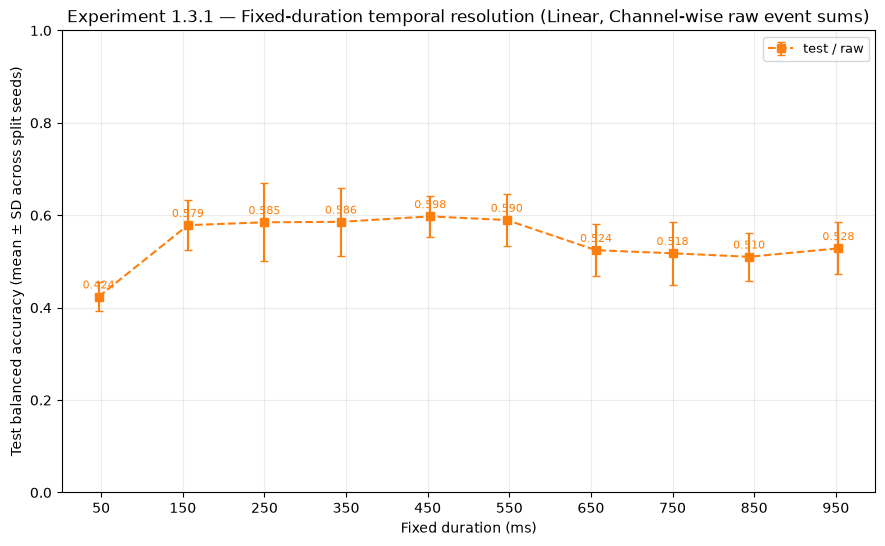

In [23]:
classifier = "linear"

fig, ax = plt.subplots(figsize=(10.5, 6.0))

sdf = main_summary[
    (main_summary["representation_family"] == "fixed_duration")
    & (main_summary["classifier"] == classifier)
    & (main_summary["eval_split"] == "test")
    & (main_summary["normalization"] == "raw")
].sort_values("actual_duration_ms")

ax.errorbar(
    sdf["actual_duration_ms"],
    sdf["mean_balanced_accuracy"],
    yerr=sdf["sd_balanced_accuracy"].fillna(0.0),
    label="test / raw",
    capsize=3,
    linestyle="--",
    marker="s",
    color="tab:orange",
)

# Annotate each mean value
for x, y in zip(
    sdf["actual_duration_ms"],
    sdf["mean_balanced_accuracy"],
):
    ax.annotate(
        f"{y:.3f}",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=8,
        color="tab:orange",
    )

# X-axis ticks: 50 ms, then every 100 ms
max_duration = sdf["actual_duration_ms"].max()
ax.set_xticks(np.arange(50, max_duration + 50, 100))

# Y-axis fixed to 0–1
ax.set_ylim(0, 1)

ax.set_xlabel("Fixed duration (ms)")
ax.set_ylabel("Test balanced accuracy (mean ± SD across split seeds)")
ax.set_title(
    "Experiment 1.3.1 — Fixed-duration temporal resolution "
    "(Linear, Channel-wise raw event sums)"
)

ax.grid(True, alpha=0.25)
ax.legend(fontsize=9)

plt.show()

## 12. Raw-vs-normalized effect

A positive value means the unnormalized fixed-bin representation outperforms the unit-total-intensity representation, indicating useful information in absolute event magnitude at that temporal scale.


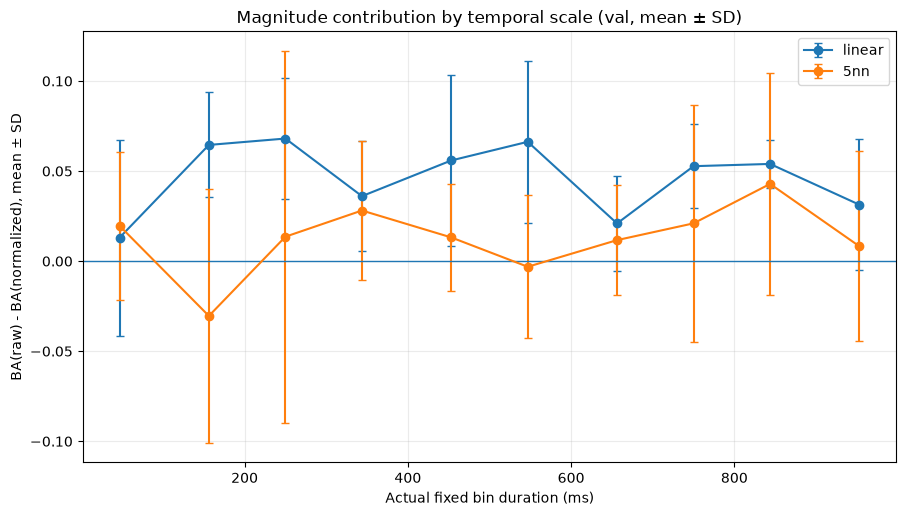

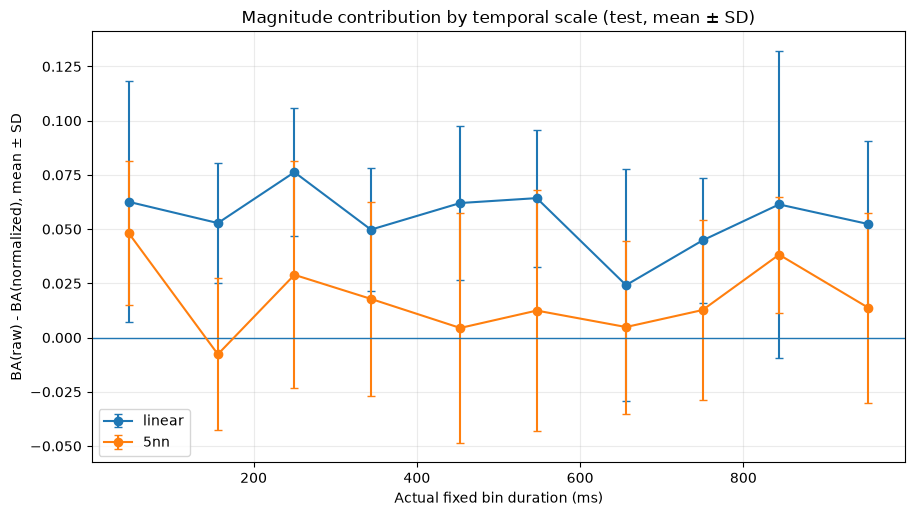

In [ ]:

for eval_split in ("val", "test"):
    sdf = fixed_results[fixed_results["eval_split"] == eval_split].copy()
    pivot = sdf.pivot_table(
        index=["split_seed", "classifier", "requested_duration_ms", "actual_duration_ms"],
        columns="normalization",
        values="balanced_accuracy",
    ).reset_index()
    pivot["raw_minus_normalized_ba"] = (
        pivot["raw"] - pivot["unit_total_intensity"]
    )
    effect_summary = (
        pivot.groupby(
            ["classifier", "requested_duration_ms", "actual_duration_ms"],
            as_index=False,
        )
        .agg(
            mean_raw_minus_normalized_ba=("raw_minus_normalized_ba", "mean"),
            sd_raw_minus_normalized_ba=("raw_minus_normalized_ba", "std"),
        )
    )

    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    for classifier in ("linear", f"{KNN_K}nn"):
        cdf = effect_summary[effect_summary["classifier"] == classifier].sort_values("actual_duration_ms")
        ax.errorbar(
            cdf["actual_duration_ms"],
            cdf["mean_raw_minus_normalized_ba"],
            yerr=cdf["sd_raw_minus_normalized_ba"].fillna(0.0),
            marker="o",
            capsize=3,
            label=classifier,
        )
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel("Actual fixed bin duration (ms)")
    ax.set_ylabel("BA(raw) - BA(normalized), mean ± SD")
    ax.set_title(f"Magnitude contribution by temporal scale ({eval_split}, mean ± SD)")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()


## 13. Validation-selected fixed-duration summary

Because the notebook sweeps 20 physical durations, the preferred duration should not be chosen by directly maximizing test accuracy. For each split seed, classifier, and normalization mode, this cell selects the duration with the highest **validation Balanced Accuracy** and reports the test metrics at that same duration. The final table aggregates those per-seed selections as mean ± SD.


In [ ]:

selection_rows = []
for split_seed in SPLIT_SEEDS:
    for classifier in ("linear", f"{KNN_K}nn"):
        for normalization in PER_BIN_NORMALIZATION_MODES:
            val_rows = fixed_results[
                (fixed_results["split_seed"] == split_seed)
                & (fixed_results["classifier"] == classifier)
                & (fixed_results["normalization"] == normalization)
                & (fixed_results["eval_split"] == "val")
            ].sort_values(
                ["balanced_accuracy", "requested_duration_ms"],
                ascending=[False, True],
            )
            if val_rows.empty:
                continue

            best_val = val_rows.iloc[0]
            test_match = fixed_results[
                (fixed_results["split_seed"] == split_seed)
                & (fixed_results["classifier"] == classifier)
                & (fixed_results["normalization"] == normalization)
                & (fixed_results["eval_split"] == "test")
                & (fixed_results["requested_duration_ms"] == best_val["requested_duration_ms"])
            ]
            if len(test_match) != 1:
                raise ValueError("Could not uniquely match validation-selected duration to test result")
            best_test = test_match.iloc[0]

            selection_rows.append({
                "split_seed": int(split_seed),
                "classifier": classifier,
                "normalization": normalization,
                "selected_requested_ms": float(best_val["requested_duration_ms"]),
                "selected_samples_per_bin": int(best_val["samples_per_bin"]),
                "selected_actual_ms": float(best_val["actual_duration_ms"]),
                "feature_dim": int(best_val["feature_dim"]),
                "val_balanced_accuracy": float(best_val["balanced_accuracy"]),
                "test_balanced_accuracy": float(best_test["balanced_accuracy"]),
                "test_accuracy": float(best_test["accuracy"]),
                "test_macro_f1": float(best_test["macro_f1"]),
            })

selection_per_seed = pd.DataFrame(selection_rows)
selection_summary = (
    selection_per_seed.groupby(["classifier", "normalization"], as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        mean_selected_requested_ms=("selected_requested_ms", "mean"),
        sd_selected_requested_ms=("selected_requested_ms", "std"),
        mean_selected_actual_ms=("selected_actual_ms", "mean"),
        sd_selected_actual_ms=("selected_actual_ms", "std"),
        val_mean_balanced_accuracy=("val_balanced_accuracy", "mean"),
        val_sd_balanced_accuracy=("val_balanced_accuracy", "std"),
        test_mean_balanced_accuracy=("test_balanced_accuracy", "mean"),
        test_sd_balanced_accuracy=("test_balanced_accuracy", "std"),
        test_mean_accuracy=("test_accuracy", "mean"),
        test_sd_accuracy=("test_accuracy", "std"),
        test_mean_macro_f1=("test_macro_f1", "mean"),
        test_sd_macro_f1=("test_macro_f1", "std"),
    )
)
if not (selection_summary["n_splits"] == len(SPLIT_SEEDS)).all():
    raise ValueError("Every selected fixed-duration summary must have one row per SPLIT_SEED")
selection_per_seed.to_csv(
    RESULTS_DIR / "experiment_1_3_1_validation_selected_fixed_duration_per_seed.csv",
    index=False,
)
selection_summary.to_csv(
    RESULTS_DIR / "experiment_1_3_1_validation_selected_fixed_duration.csv",
    index=False,
)
display(selection_per_seed)
display(selection_summary)


,split_seed,classifier,normalization,selected_requested_ms,selected_samples_per_bin,selected_actual_ms,feature_dim,val_balanced_accuracy,test_balanced_accuracy,test_accuracy,test_macro_f1
0,11,linear,raw,350.0,22,343.750,360,0.486477,0.696276,0.697115,0.688437
1,11,linear,unit_total_intensity,450.0,29,453.125,270,0.468113,0.601389,0.600962,0.598339
2,11,5nn,raw,450.0,29,453.125,270,0.366960,0.512657,0.524038,0.510136
3,11,5nn,unit_total_intensity,950.0,61,953.125,150,0.370108,0.391782,0.408654,0.358460
4,23,linear,raw,150.0,10,156.250,780,0.621750,0.552953,0.576271,0.555876
5,23,linear,unit_total_intensity,350.0,22,343.750,360,0.568866,0.476859,0.485876,0.487139
6,23,5nn,raw,950.0,61,953.125,150,0.411953,0.380790,0.395480,0.368956
7,23,5nn,unit_total_intensity,250.0,16,250.000,480,0.460482,0.383742,0.389831,0.385704
8,37,linear,raw,250.0,16,250.000,480,0.646467,0.610290,0.601266,0.596174
9,37,linear,unit_total_intensity,450.0,29,453.125,270,0.603983,0.517859,0.506329,0.500816


,classifier,normalization,n_splits,mean_selected_requested_ms,sd_selected_requested_ms,mean_selected_actual_ms,sd_selected_actual_ms,val_mean_balanced_accuracy,val_sd_balanced_accuracy,test_mean_balanced_accuracy,test_sd_balanced_accuracy,test_mean_accuracy,test_sd_accuracy,test_mean_macro_f1,test_sd_macro_f1
0,5nn,raw,5,490.0,260.768096,487.500,264.565903,0.470196,0.075427,0.460270,0.056804,0.468035,0.056209,0.453904,0.060042
1,5nn,unit_total_intensity,5,490.0,279.284801,487.500,281.986882,0.455787,0.050887,0.404470,0.042427,0.412090,0.043485,0.387515,0.037776
2,linear,raw,5,310.0,114.017543,309.375,111.803399,0.622862,0.080598,0.607833,0.053639,0.612073,0.048660,0.604784,0.049979
3,linear,unit_total_intensity,5,410.0,54.772256,409.375,59.907155,0.580241,0.068618,0.525645,0.045739,0.528792,0.043583,0.522970,0.043612


## 14. Compact representation comparison

This table places the main temporal representations side by side using test Balanced Accuracy mean ± SD across the five split seeds:

- whole-gesture count (`relative_1bin`),
- relative 10-bin phase representation,
- raw timestep flatten,
- validation-selected fixed-duration raw / normalized representations.

Interpret the fixed-duration winner as the best **rectangular fixed-window aggregation representation** in this sweep, not as a direct estimate of an optimal SNN `tau_syn`.


In [ ]:

def get_main_summary_row(classifier: str, family: str, condition: str, eval_split: str) -> pd.Series:
    row = main_summary[
        (main_summary["classifier"] == classifier)
        & (main_summary["representation_family"] == family)
        & (main_summary["condition"] == condition)
        & (main_summary["eval_split"] == eval_split)
    ]
    if len(row) != 1:
        raise ValueError(f"Expected one summary row, got {len(row)}")
    return row.iloc[0]


comparison_rows = []
for classifier in ("linear", f"{KNN_K}nn"):
    for n_bins, name in ((1, "whole_count"), (RELATIVE_REFERENCE_N_BINS, "relative_10bin")):
        row = get_main_summary_row(
            classifier, "relative_progress", f"relative_{n_bins}bin", "test"
        )
        comparison_rows.append({
            "classifier": classifier,
            "representation": name,
            "detail": f"{n_bins} relative bin(s)",
            "feature_dim": int(row["feature_dim"]),
            "test_mean_balanced_accuracy": float(row["mean_balanced_accuracy"]),
            "test_sd_balanced_accuracy": float(row["sd_balanced_accuracy"]),
        })

    row = get_main_summary_row(
        classifier, "raw_timestep", "raw_timestep_flatten", "test"
    )
    comparison_rows.append({
        "classifier": classifier,
        "representation": "raw_timestep_flatten",
        "detail": f"1 sample = {1000.0 / SAMPLING_RATE_HZ:.3f} ms",
        "feature_dim": int(row["feature_dim"]),
        "test_mean_balanced_accuracy": float(row["mean_balanced_accuracy"]),
        "test_sd_balanced_accuracy": float(row["sd_balanced_accuracy"]),
    })

    for normalization in PER_BIN_NORMALIZATION_MODES:
        selected = selection_summary[
            (selection_summary["classifier"] == classifier)
            & (selection_summary["normalization"] == normalization)
        ].iloc[0]
        comparison_rows.append({
            "classifier": classifier,
            "representation": f"best_fixed_{normalization}",
            "detail": (
                f"mean selected = {selected['mean_selected_actual_ms']:.3f} ± "
                f"{selected['sd_selected_actual_ms']:.3f} ms"
            ),
            "feature_dim": np.nan,
            "test_mean_balanced_accuracy": float(selected["test_mean_balanced_accuracy"]),
            "test_sd_balanced_accuracy": float(selected["test_sd_balanced_accuracy"]),
        })

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(
    RESULTS_DIR / "experiment_1_3_1_compact_representation_comparison.csv",
    index=False,
)
display(comparison)


,classifier,representation,detail,feature_dim,test_mean_balanced_accuracy,test_sd_balanced_accuracy
0,linear,whole_count,1 relative bin(s),30.0,0.401739,0.035195
1,linear,relative_10bin,10 relative bin(s),300.0,0.714740,0.077896
2,linear,raw_timestep_flatten,1 sample = 15.625 ms,7680.0,0.305198,0.029454
3,linear,best_fixed_raw,mean selected = 309.375 ± 111.803 ms,NaN,0.607833,0.053639
4,linear,best_fixed_unit_total_intensity,mean selected = 409.375 ± 59.907 ms,NaN,0.525645,0.045739
5,5nn,whole_count,1 relative bin(s),30.0,0.273695,0.040162
6,5nn,relative_10bin,10 relative bin(s),300.0,0.525050,0.088158
7,5nn,raw_timestep_flatten,1 sample = 15.625 ms,7680.0,0.078375,0.005053
8,5nn,best_fixed_raw,mean selected = 487.500 ± 264.566 ms,NaN,0.460270,0.056804
9,5nn,best_fixed_unit_total_intensity,mean selected = 487.500 ± 281.987 ms,NaN,0.404470,0.042427


LINEAR PROBE CONFUSION MATRIX
Condition:       fixed_0450ms_raw
Representation:  requested=450 ms | actual=453.125 ms | 29 samples/bin | 9 bins | normalization=raw
Eval split:      test
Feature dim:     270
Train samples:   632
Eval samples:    95

Accuracy:          0.5474
Balanced Accuracy: 0.5521
Macro-F1:          0.5515

Classes:
['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']


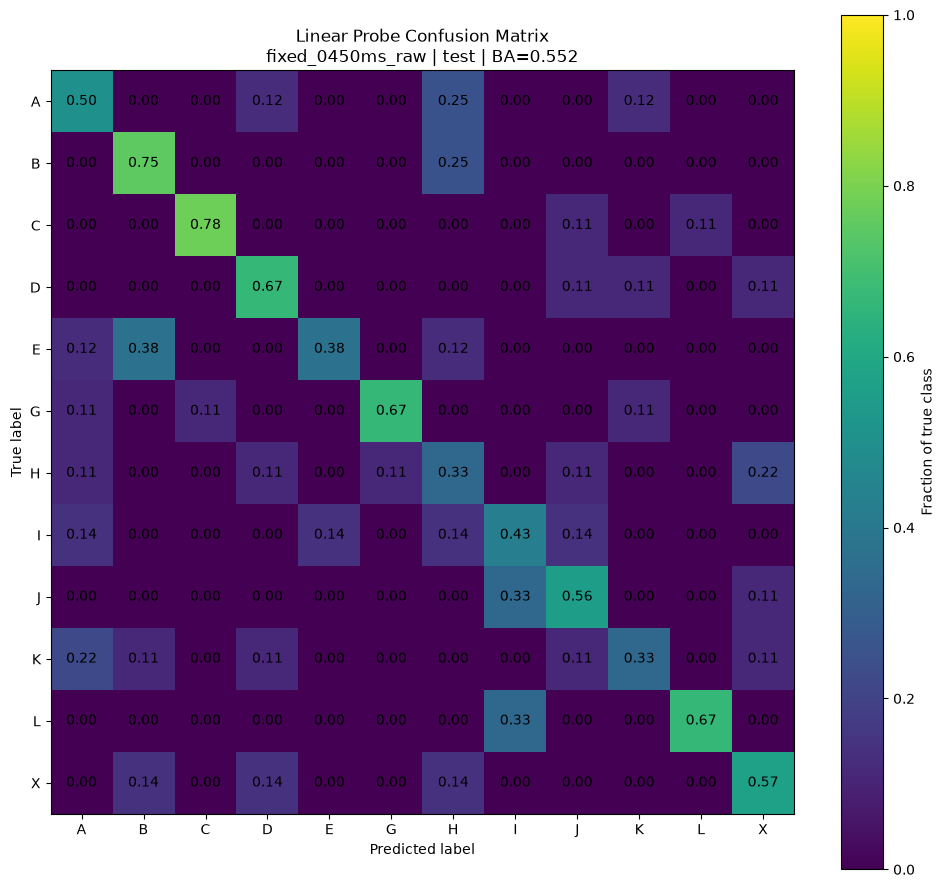

,pred_A,pred_B,pred_C,pred_D,pred_E,pred_G,pred_H,pred_I,pred_J,pred_K,pred_L,pred_X
true_A,4,0,0,1,0,0,2,0,0,1,0,0
true_B,0,6,0,0,0,0,2,0,0,0,0,0
true_C,0,0,7,0,0,0,0,0,1,0,1,0
true_D,0,0,0,6,0,0,0,0,1,1,0,1
true_E,1,3,0,0,3,0,1,0,0,0,0,0
true_G,1,0,1,0,0,6,0,0,0,1,0,0
true_H,1,0,0,1,0,1,3,0,1,0,0,2
true_I,1,0,0,0,1,0,1,3,1,0,0,0
true_J,0,0,0,0,0,0,0,3,5,0,0,1
true_K,2,1,0,1,0,0,0,0,1,3,0,1



Top 15 off-diagonal confusions:


,true_label,predicted_label,confusion_rate,count
0,E,B,0.375000,3
1,J,I,0.333333,3
2,L,I,0.333333,1
3,A,H,0.250000,2
4,B,H,0.250000,2
5,H,X,0.222222,2
6,K,A,0.222222,2
7,I,A,0.142857,1
8,I,E,0.142857,1
9,I,H,0.142857,1


In [ ]:
# =============================================================================
# Linear-probe confusion matrix for a selected temporal representation
# =============================================================================
#
# Change ONLY CM_CONDITION to select the representation.
#
# Examples:
#   "relative_1bin"
#   "relative_4bin"
#   "relative_10bin"
#   "relative_20bin"
#   "raw_timestep_flatten"
#
#   "fixed_0050ms_raw"
#   "fixed_0150ms_raw"
#   "fixed_0250ms_raw"
#   "fixed_0350ms_raw"
#   "fixed_0450ms_raw"
#   ...
#   "fixed_0950ms_raw"
#
#   "fixed_0250ms_unit_total_intensity"
#   "fixed_0450ms_unit_total_intensity"
#   ...
#
# Fixed duration must be one of FIXED_DURATIONS_MS defined earlier.
# =============================================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.linear_model import LogisticRegression
import re

# -----------------------------------------------------------------------------
# USER SELECTION
# -----------------------------------------------------------------------------

CM_CONDITION = "fixed_0450ms_raw"

# "val" or "test"
CM_EVAL_SPLIT = "test"

# "true" = each row sums to 1, recommended for class-balanced interpretation
CM_NORMALIZE = "true"

# Show numeric value inside every cell
CM_ANNOTATE = True


# -----------------------------------------------------------------------------
# Build selected representation
# -----------------------------------------------------------------------------

def build_selected_cm_features(condition: str):

    # -------------------------------------------------------------------------
    # Relative-progress representation
    # -------------------------------------------------------------------------
    match = re.fullmatch(r"relative_(\d+)bin", condition)

    if match is not None:
        n_bins = int(match.group(1))

        if n_bins not in RELATIVE_N_BINS:
            raise ValueError(
                f"{condition}: n_bins={n_bins} is not in "
                f"RELATIVE_N_BINS={RELATIVE_N_BINS}"
            )

        tr_bins, ytr, _ = temporal_bin_features(
            data,
            train_df,
            n_bins,
        )
        va_bins, yva, _ = temporal_bin_features(
            data,
            val_df,
            n_bins,
        )
        te_bins, yte, _ = temporal_bin_features(
            data,
            test_df,
            n_bins,
        )

        Xtr = flatten_bins(tr_bins)
        Xva = flatten_bins(va_bins)
        Xte = flatten_bins(te_bins)

        detail = (
            f"{n_bins} relative-progress bins "
            f"({100.0 / n_bins:.1f}% gesture/bin)"
        )

        return Xtr, ytr, Xva, yva, Xte, yte, detail

    # -------------------------------------------------------------------------
    # Raw timestep flatten
    # -------------------------------------------------------------------------
    if condition == "raw_timestep_flatten":

        Xtr = raw_flatten_features(X_train_padded)
        Xva = raw_flatten_features(X_val_padded)
        Xte = raw_flatten_features(X_test_padded)

        detail = (
            f"raw timestep flatten | "
            f"1 timestep = {1000.0 / SAMPLING_RATE_HZ:.3f} ms | "
            f"feature dim = {Xtr.shape[1]}"
        )

        return (
            Xtr,
            y_train,
            Xva,
            y_val,
            Xte,
            y_test,
            detail,
        )

    # -------------------------------------------------------------------------
    # Fixed-duration representation
    # -------------------------------------------------------------------------
    match = re.fullmatch(
        r"fixed_(\d+)ms_(raw|unit_total_intensity)",
        condition,
    )

    if match is not None:
        requested_ms = int(match.group(1))
        normalization = match.group(2)

        if requested_ms not in FIXED_DURATIONS_MS:
            raise ValueError(
                f"{requested_ms} ms is not in "
                f"FIXED_DURATIONS_MS={FIXED_DURATIONS_MS}"
            )

        samples_per_bin = duration_ms_to_samples(
            requested_ms,
            SAMPLING_RATE_HZ,
        )

        actual_ms = (
            samples_per_bin
            / SAMPLING_RATE_HZ
            * 1000.0
        )

        tr_bins = fixed_duration_bin_features(
            X_train_padded,
            samples_per_bin,
            normalization,
        )
        va_bins = fixed_duration_bin_features(
            X_val_padded,
            samples_per_bin,
            normalization,
        )
        te_bins = fixed_duration_bin_features(
            X_test_padded,
            samples_per_bin,
            normalization,
        )

        Xtr = flatten_bins(tr_bins)
        Xva = flatten_bins(va_bins)
        Xte = flatten_bins(te_bins)

        detail = (
            f"requested={requested_ms} ms | "
            f"actual={actual_ms:.3f} ms | "
            f"{samples_per_bin} samples/bin | "
            f"{tr_bins.shape[1]} bins | "
            f"normalization={normalization}"
        )

        return (
            Xtr,
            y_train,
            Xva,
            y_val,
            Xte,
            y_test,
            detail,
        )

    raise ValueError(
        f"Unknown CM_CONDITION: {condition!r}\n\n"
        "Examples:\n"
        "  relative_1bin\n"
        "  relative_4bin\n"
        "  relative_10bin\n"
        "  relative_20bin\n"
        "  raw_timestep_flatten\n"
        "  fixed_0250ms_raw\n"
        "  fixed_0250ms_unit_total_intensity"
    )


# -----------------------------------------------------------------------------
# Construct features
# -----------------------------------------------------------------------------

(
    Xtr,
    ytr,
    Xva,
    yva,
    Xte,
    yte,
    representation_detail,
) = build_selected_cm_features(CM_CONDITION)


# -----------------------------------------------------------------------------
# EXACT SAME train-only standardization protocol as notebook
# -----------------------------------------------------------------------------

Xtr_z, Xva_z, Xte_z = standardize_from_train(
    Xtr,
    Xva,
    Xte,
)


# -----------------------------------------------------------------------------
# Fit Linear probe
# -----------------------------------------------------------------------------

probe_seed = derive_seed(
    SPLIT_SEED,
    CM_CONDITION,
    "logreg",
)

linear_probe = LogisticRegression(
    max_iter=LOGREG_MAX_ITER,
    random_state=probe_seed,
    solver="lbfgs",
)

linear_probe.fit(
    Xtr_z,
    ytr,
)


# -----------------------------------------------------------------------------
# Select validation or test set
# -----------------------------------------------------------------------------

if CM_EVAL_SPLIT == "val":
    X_eval = Xva_z
    y_eval = yva

elif CM_EVAL_SPLIT == "test":
    X_eval = Xte_z
    y_eval = yte

else:
    raise ValueError(
        "CM_EVAL_SPLIT must be 'val' or 'test'"
    )


# -----------------------------------------------------------------------------
# Prediction + metrics
# -----------------------------------------------------------------------------

y_pred = linear_probe.predict(X_eval)

acc = accuracy_score(
    y_eval,
    y_pred,
)

ba = balanced_accuracy_score(
    y_eval,
    y_pred,
)

macro_f1 = f1_score(
    y_eval,
    y_pred,
    average="macro",
    zero_division=0,
)


# -----------------------------------------------------------------------------
# Confusion matrices
# -----------------------------------------------------------------------------

class_indices = np.arange(len(labels_sorted))

cm_counts = confusion_matrix(
    y_eval,
    y_pred,
    labels=class_indices,
)

cm = confusion_matrix(
    y_eval,
    y_pred,
    labels=class_indices,
    normalize=CM_NORMALIZE,
)


# -----------------------------------------------------------------------------
# Report
# -----------------------------------------------------------------------------

print("=" * 100)
print("LINEAR PROBE CONFUSION MATRIX")
print("=" * 100)

print("Condition:      ", CM_CONDITION)
print("Representation: ", representation_detail)
print("Eval split:     ", CM_EVAL_SPLIT)
print("Feature dim:    ", Xtr.shape[1])
print("Train samples:  ", len(ytr))
print("Eval samples:   ", len(y_eval))

print()
print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {ba:.4f}")
print(f"Macro-F1:          {macro_f1:.4f}")

print()
print("Classes:")
print(labels_sorted)


# -----------------------------------------------------------------------------
# Plot normalized confusion matrix
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9),
)

im = ax.imshow(
    cm,
    vmin=0.0,
    vmax=1.0 if CM_NORMALIZE is not None else None,
)

ax.set_xticks(
    np.arange(len(labels_sorted)),
)
ax.set_yticks(
    np.arange(len(labels_sorted)),
)

ax.set_xticklabels(
    labels_sorted,
)
ax.set_yticklabels(
    labels_sorted,
)

ax.set_xlabel(
    "Predicted label",
)
ax.set_ylabel(
    "True label",
)

ax.set_title(
    f"Linear Probe Confusion Matrix\n"
    f"{CM_CONDITION} | {CM_EVAL_SPLIT} | "
    f"BA={ba:.3f}"
)

if CM_ANNOTATE:
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            if CM_NORMALIZE is None:
                text = f"{cm[i, j]:.0f}"
            else:
                text = f"{cm[i, j]:.2f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
            )

fig.colorbar(
    im,
    ax=ax,
    label=(
        "Fraction of true class"
        if CM_NORMALIZE == "true"
        else "Count"
    ),
)

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# Show raw-count confusion matrix as a dataframe
# -----------------------------------------------------------------------------

cm_count_df = pd.DataFrame(
    cm_counts,
    index=[
        f"true_{label}"
        for label in labels_sorted
    ],
    columns=[
        f"pred_{label}"
        for label in labels_sorted
    ],
)

display(cm_count_df)


# -----------------------------------------------------------------------------
# Top off-diagonal confusions
# -----------------------------------------------------------------------------

confusion_pairs = []

for i, true_label in enumerate(labels_sorted):
    for j, pred_label in enumerate(labels_sorted):

        if i == j:
            continue

        confusion_pairs.append({
            "true_label": true_label,
            "predicted_label": pred_label,
            "confusion_rate": float(cm[i, j]),
            "count": int(cm_counts[i, j]),
        })

confusion_pairs = pd.DataFrame(
    confusion_pairs
).sort_values(
    ["confusion_rate", "count"],
    ascending=False,
).reset_index(
    drop=True,
)

print()
print("Top 15 off-diagonal confusions:")
display(
    confusion_pairs.head(15)
)

## Interpretation guide

All reported representation metrics are aggregated over the five user-disjoint split seeds as mean ± sample SD. Use the results to separate three forms of temporal information:

- **Relative gesture phase:** if relative 10-bin remains stronger than fixed-duration and raw absolute-time representations, speed/duration variation is likely important and relative alignment helps.
- **Fine absolute timing:** if raw timestep flatten clearly exceeds coarser representations, useful discrimination remains at the timestep scale.
- **Fixed physical timescale:** if a particular fixed-duration region peaks, rectangular integration over that physical timescale is useful; this does **not** directly imply the same optimal exponential synaptic time constant.

For the normalization control:

- `raw ≈ unit_total_intensity` suggests within-bin **30-channel activity composition** carries most of the useful information.
- `raw > unit_total_intensity` suggests **absolute event intensity / magnitude** contributes additional discriminative information.

For Linear vs 5-NN:

- strong Linear and 5-NN performance indicates both global linear separability and useful local class neighborhoods;
- strong Linear but weaker 5-NN suggests the representation is linearly decodable without especially compact Euclidean class clusters;
- strong 5-NN but weaker Linear suggests useful local clustering with a less globally linear decision geometry.
